In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [4]:
df = pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

le = LabelEncoder()
text_columns = df.select_dtypes(include=['object']).columns

for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("Data cleaning and encoding finished.")
df.head()


Data cleaning and encoding finished.


C:\Users\shubh\AppData\Local\Temp\ipykernel_10468\3244380292.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


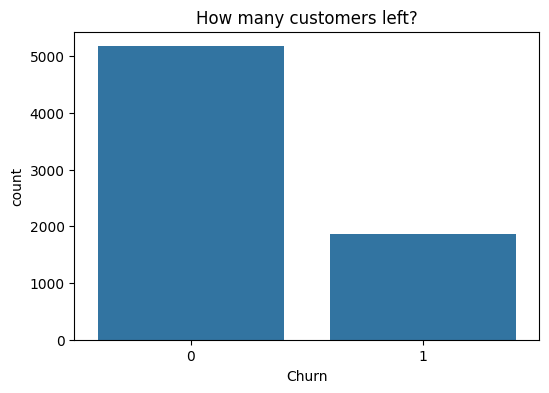

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('How many customers left?')
plt.show()

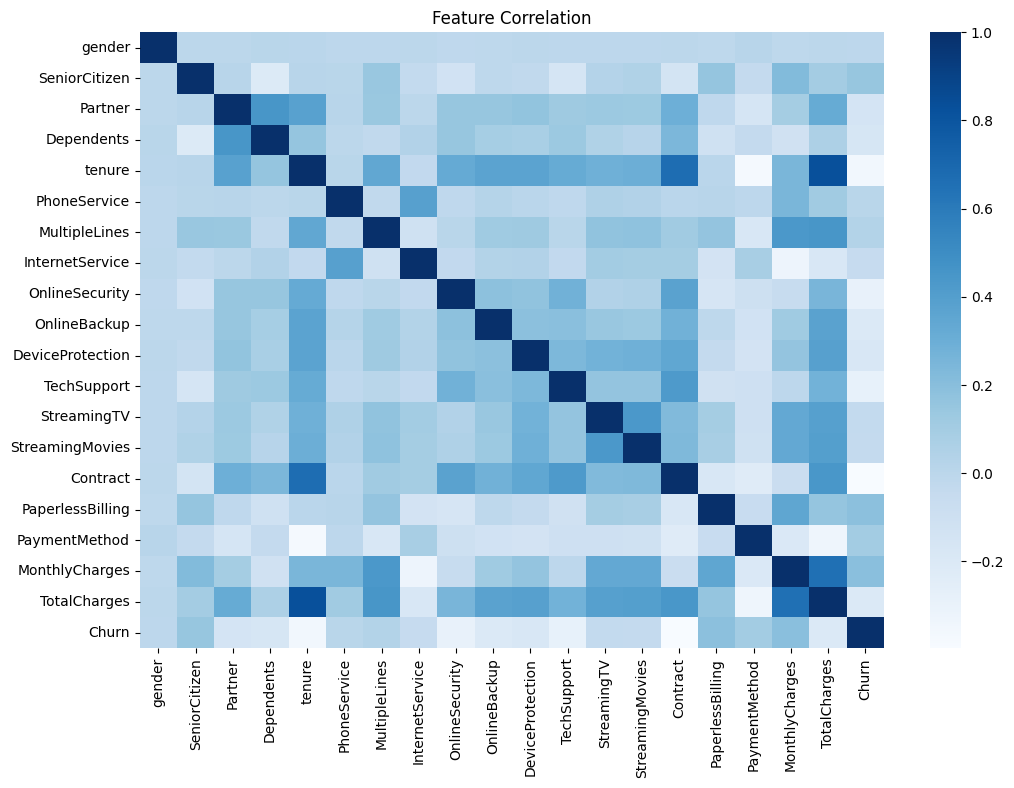

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='Blues')
plt.title('Feature Correlation')
plt.show()

In [9]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train_scaled, y_train)
lr_preds = lr_model.predict(x_test_scaled)

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)
rf_preds = rf_model.predict(x_test_scaled)

In [17]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds) * 100:.2f}%")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")

Logistic Regression Accuracy: 81.55%
Random Forest Accuracy: 79.63%


In [18]:
print("--- Detailed Evaluation (Random Forest) ---")
print(confusion_matrix(y_test, rf_preds))
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

with open('churn_model.pkl', 'wb') as model_file:
    pickle.dump(rf_model, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Files saved: churn_model.pkl and scaler.pkl")


--- Detailed Evaluation (Random Forest) ---
[[946  90]
 [197 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

Files saved: churn_model.pkl and scaler.pkl


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

y_pred = rf_model.predict(x_test_scaled)
y_prob = rf_model.predict_proba(x_test_scaled)

acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
loss = log_loss(y_test, y_prob)

print("--- Customer Churn Model Results ---")
print(f"1. Accuracy: {acc*100:.2f}% (How many total guesses were right)")
print(f"2. Log Loss: {loss:.4f} (Lower means the model is more confident)")

print("\n3. Confusion Matrix:")
print(conf_matrix)

print("\n4. Detailed Classification Report:")
print(classification_report(y_test, y_pred))


--- Customer Churn Model Results ---
1. Accuracy: 79.63% (How many total guesses were right)
2. Log Loss: 0.4479 (Lower means the model is more confident)

3. Confusion Matrix:
[[946  90]
 [197 176]]

4. Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

